<a href="https://colab.research.google.com/github/SvisTheCoder/Projet-Annuel-3e-ann-e/blob/prototype/Lin%C3%A9raire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1) Classification linéaire avec la règle de Rosenblatt

Poids : [0.05 0.2 ]
Biais : -0.7
Prédictions : [-1 -1 -1 -1  1  1  1  1]
Accuracy : 1.0


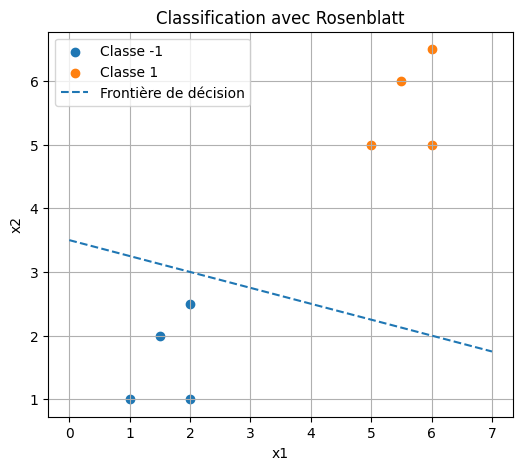

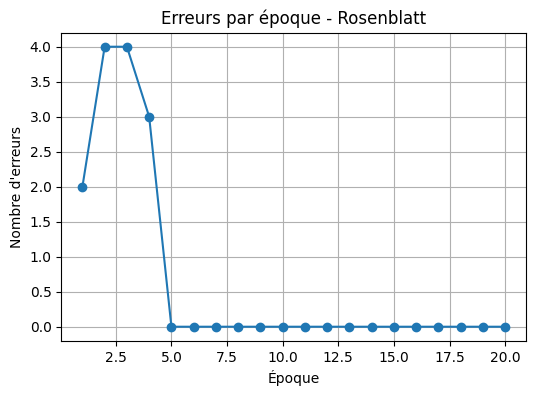

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Données de classification
# =========================
X = np.array([
    [1, 1],
    [1.5, 2],
    [2, 1],
    [2, 2.5],
    [5, 5],
    [6, 5],
    [5.5, 6],
    [6, 6.5]
], dtype=float)

# Labels en {-1, +1}
y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])


# =========================
# Modèle de Rosenblatt
# =========================
class RosenblattPerceptron:
    def __init__(self, learning_rate=0.1, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            errors = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else -1

                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1

            self.errors_per_epoch.append(errors)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# =========================
# Entraînement
# =========================
model = RosenblattPerceptron(learning_rate=0.1, epochs=20)
model.fit(X, y)

print("Poids :", model.weights)
print("Biais :", model.bias)
print("Prédictions :", model.predict(X))
print("Accuracy :", model.score(X, y))


# =========================
# Visualisation des points
# =========================
plt.figure(figsize=(6, 5))
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Classe {label}")

# Frontière de décision : w1*x + w2*y + b = 0
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_values = np.array([x_min, x_max])

if model.weights[1] != 0:
    y_values = -(model.weights[0] * x_values + model.bias) / model.weights[1]
    plt.plot(x_values, y_values, linestyle="--", label="Frontière de décision")

plt.title("Classification avec Rosenblatt")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Visualisation des erreurs
# =========================
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model.errors_per_epoch) + 1), model.errors_per_epoch, marker='o')
plt.title("Erreurs par époque - Rosenblatt")
plt.xlabel("Époque")
plt.ylabel("Nombre d'erreurs")
plt.grid(True)
plt.show()

2) Modèle linéaire de régression avec la pseudo-inverse de Moore-Penrose

Poids [biais, coefficient] : [1.11785714 1.98214286]
Prédictions : [ 3.1         5.08214286  7.06428571  9.04642857 11.02857143 13.01071429
 14.99285714 16.975     ]
MSE : 0.01566964285714275


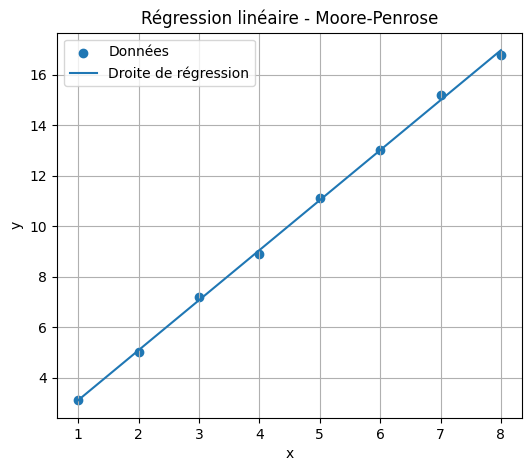

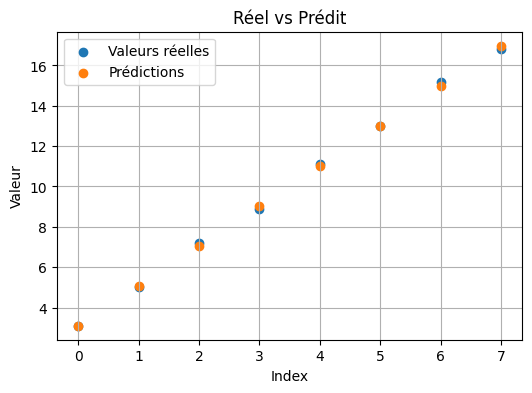

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Données de régression
# =========================
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]], dtype=float)
y = np.array([3.1, 5.0, 7.2, 8.9, 11.1, 13.0, 15.2, 16.8], dtype=float)
# En gros proche de y = 2x + 1


# =========================
# Modèle Moore-Penrose
# =========================
class LinearRegressionMoorePenrose:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Ajout du biais
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        self.weights = np.linalg.pinv(X_bias) @ y

    def predict(self, X):
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        return X_bias @ self.weights

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)


# =========================
# Entraînement
# =========================
model = LinearRegressionMoorePenrose()
model.fit(X, y)

y_pred = model.predict(X)

print("Poids [biais, coefficient] :", model.weights)
print("Prédictions :", y_pred)
print("MSE :", model.mse(X, y))


# =========================
# Visualisation
# =========================
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], y, label="Données")

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Droite de régression")
plt.title("Régression linéaire - Moore-Penrose")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Comparaison vraie valeur / prédiction
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(range(len(y)), y, label="Valeurs réelles")
plt.scatter(range(len(y_pred)), y_pred, label="Prédictions")
plt.title("Réel vs Prédit")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.show()

3) PMC avec SGD en classification binaire

Probabilités : [5.16926499e-04 1.65267510e-03 1.61107661e-03 5.12625365e-04
 9.98991558e-01 9.99318490e-01 9.99316054e-01 9.98981429e-01]
Prédictions : [0 0 0 0 1 1 1 1]
Accuracy : 1.0


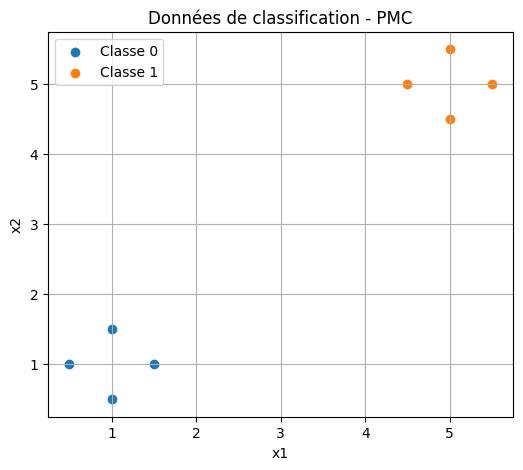

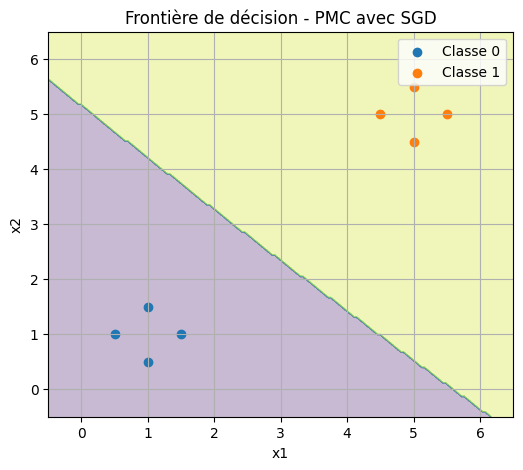

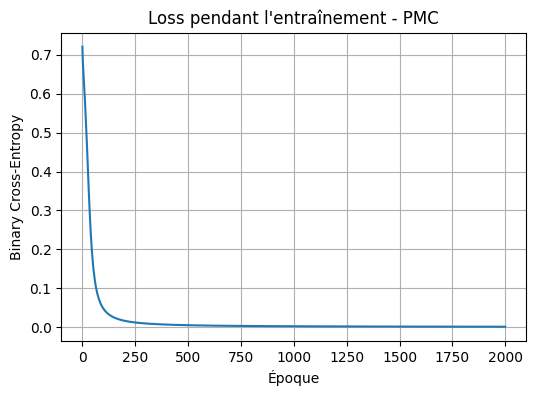

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Données de classification
# =========================
X = np.array([
    [0.5, 1.0],
    [1.0, 1.5],
    [1.5, 1.0],
    [1.0, 0.5],
    [4.5, 5.0],
    [5.0, 5.5],
    [5.5, 5.0],
    [5.0, 4.5]
], dtype=float)

# Labels en {0, 1}
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])


# =========================
# PMC (MLP) avec SGD
# =========================
class MLPBinaryClassifier:
    def __init__(self, input_size, hidden_size, learning_rate=0.1, epochs=2000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * 0.5
        self.b2 = np.zeros((1, 1))

        self.loss_history = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def binary_cross_entropy(self, y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.sigmoid(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)

        return z1, a1, z2, a2

    def fit(self, X, y):
        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(X.shape[0]):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]

                # Forward
                z1, a1, z2, a2 = self.forward(xi)

                # Backprop
                error_output = a2 - yi
                dW2 = a1.T @ error_output
                db2 = error_output

                error_hidden = (error_output @ self.W2.T) * self.sigmoid_derivative(a1)
                dW1 = xi.T @ error_hidden
                db1 = error_hidden

                # Mise à jour SGD
                self.W2 -= self.learning_rate * dW2
                self.b2 -= self.learning_rate * db2
                self.W1 -= self.learning_rate * dW1
                self.b1 -= self.learning_rate * db1

            # Calcul de la loss sur tout le dataset
            _, _, _, y_pred_all = self.forward(X)
            loss = self.binary_cross_entropy(y, y_pred_all)
            self.loss_history.append(loss)

    def predict_proba(self, X):
        _, _, _, a2 = self.forward(X)
        return a2

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= 0.5).astype(int).flatten()

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# =========================
# Entraînement
# =========================
np.random.seed(42)
model = MLPBinaryClassifier(input_size=2, hidden_size=4, learning_rate=0.1, epochs=2000)
model.fit(X, y)

print("Probabilités :", model.predict_proba(X).flatten())
print("Prédictions :", model.predict(X))
print("Accuracy :", model.score(X, y))


# =========================
# Visualisation des points
# =========================
plt.figure(figsize=(6, 5))
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Classe {label}")

plt.title("Données de classification - PMC")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Visualisation de la frontière
# =========================
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3)

for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Classe {label}")

plt.title("Frontière de décision - PMC avec SGD")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Visualisation de la loss
# =========================
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.title("Loss pendant l'entraînement - PMC")
plt.xlabel("Époque")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True)
plt.show()